# Import Required Libraries

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load Dataset

In [49]:
df=pd.read_csv("house price prediction.csv.xls")
df.head(2)

,bath,balcony,price,total_sqft_int,bhk,price_per_sqft,area_typeSuper built-up Area,area_typeBuilt-up Area,area_typePlot Area,availability_Ready To Move,...,location_Kalena Agrahara,location_Horamavu Agara,location_Vidyaranyapura,location_BTM 2nd Stage,location_Hebbal Kempapura,location_Hosur Road,location_Horamavu Banaswadi,location_Domlur,location_Mahadevpura,location_Tumkur Road
0,3.0,2.0,150.0,1672.0,3,8971.291866,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,3.0,3.0,149.0,1750.0,3,8514.285714,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0


# Checking Missing Values

In [26]:
df.isnull().sum()

bath                           0
balcony                        0
price                          0
total_sqft_int                 0
bhk                            0
                              ..
location_Hosur Road            0
location_Horamavu Banaswadi    0
location_Domlur                0
location_Mahadevpura           0
location_Tumkur Road           0
Length: 108, dtype: int64

# Dataset Information

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7120 entries, 0 to 7119
Columns: 108 entries, bath to location_Tumkur Road
dtypes: float64(5), int64(103)
memory usage: 5.9 MB


# Feature & Target Selection

In [28]:

x=df.drop('price',axis=1)
y=df['price']

print("Shape of x:",x.shape)
print("Shape of y:",y.shape)

Shape of x: (7120, 107)
Shape of y: (7120,)


# Train Test Split

In [29]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=200)

In [30]:
print("x_train shape:",x_train.shape)
print("x_test shape:",x_test.shape)

x_train shape: (5696, 107)
x_test shape: (1424, 107)


In [31]:
print("y_train shape:",y_train.shape)
print("y_test shape:",y_test.shape)

y_train shape: (5696,)
y_test shape: (1424,)


In [ ]:
# 

In [32]:
df.describe()

,bath,balcony,price,total_sqft_int,bhk,price_per_sqft,area_typeSuper built-up Area,area_typeBuilt-up Area,area_typePlot Area,availability_Ready To Move,...,location_Kalena Agrahara,location_Horamavu Agara,location_Vidyaranyapura,location_BTM 2nd Stage,location_Hebbal Kempapura,location_Hosur Road,location_Horamavu Banaswadi,location_Domlur,location_Mahadevpura,location_Tumkur Road
count,7120.000000,7120.000000,7120.000000,7120.000000,7120.000000,7120.000000,7120.000000,7120.000000,7120.000000,7120.000000,...,7120.000000,7120.000000,7120.000000,7120.000000,7120.000000,7120.000000,7120.000000,7120.000000,7120.000000,7120.000000
mean,2.390871,1.572759,96.454991,1479.729806,2.465169,5923.806855,0.750702,0.182303,0.061938,0.792697,...,0.003090,0.003090,0.002949,0.002949,0.002949,0.002949,0.002809,0.002809,0.002809,0.002809
std,0.876822,0.770583,116.185034,913.779769,0.841520,2556.650935,0.432637,0.386121,0.241060,0.405403,...,0.055505,0.055505,0.054232,0.054232,0.054232,0.054232,0.052929,0.052929,0.052929,0.052929
min,1.000000,0.000000,10.000000,350.000000,1.000000,1250.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,1.000000,49.230000,1100.000000,2.000000,4416.761042,1.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2.000000,2.000000,69.000000,1255.000000,2.000000,5417.855613,1.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,3.000000,2.000000,104.000000,1640.250000,3.000000,6618.285651,1.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,9.000000,3.000000,2912.000000,30400.000000,9.000000,35000.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# Feature Scaling

In [33]:

from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
sc.fit(x_train)
x_train=sc.transform(x_train)
x_test=sc.transform(x_test)

# Model Training (Multiple Linear Regression)

In [50]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)

LinearRegression()

# Model Evaluation (Before Prediction)

In [36]:
lr.score(x_test,y_test)

0.8287379764174044

# Prediction

In [38]:
lr.predict([x_test[0,:]])

array([17.46265434])

# Error Metrics

In [39]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [40]:
y_pred=lr.predict(x_test)
x_pred=lr.predict(x_train)

# Visualization (Graph)

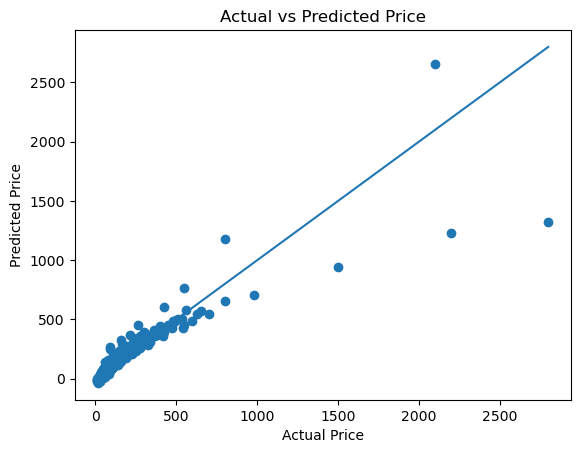

In [46]:
plt.scatter(y_test, y_pred)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.show()

In [41]:
#MAE
print("MAE Value:",mean_absolute_error(y_test,y_pred))  #(y_test: actual data,y_pred: predicted data)

MAE Value: 18.290047611465823


In [42]:
#MSE
print("MSE Value:",mean_squared_error(y_test,y_pred))

MSE Value: 3427.592317728856


In [43]:
#RMSE
print("RMSE Value:",np.sqrt(mean_squared_error(y_test,y_pred)))

RMSE Value: 58.545643029424966


In [44]:
#R2_Score
print("R2_Score:",r2_score(y_test,y_pred))

R2_Score: 0.8287379764174044


# Overfitting Check (Training vs Testing Score)

In [47]:
print("Training Score:",lr.score(x_train,y_train))
print("Testing Score:",lr.score(x_test,y_test))

Training Score: 0.8671942413495295
Testing Score: 0.8287379764174044


# Conclusion

In this project, Multiple Linear Regression was used to predict house prices.
The model was trained and evaluated using different performance metrics such as MAE, MSE, RMSE, and R² score.

The visualization between actual and predicted values shows that most predictions lie close to the ideal line, indicating good model performance.